## Final Project for EE 395: Scientific Machine Learning

The Van Der Pol oscillator can be written as:
$$\ddot{x} - \mu(1-x^2)\dot{x} + x = 0$$

Alternatively, as a system of two first-order ODEs:
$$x' = y$$
$$y' = \mu(1-x^2)y - x$$

The forced Van Der Pol oscillator:
$$x' = y$$
$$y' = \mu(1-x^2)y - x + A\sin(\omega t)$$


This notebook is a runthrough of my project and the various methods I employed to attempt to model these oscillators.

### This is where the tunable hyperparameters are

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pickle

from numerical import euler, rk4
from ann import train_ffnn
from neural_ode import train_neural_ode, euler_for_node
from pinn import train_pinn, pinn_predict

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = "cpu" # you can change to "cuda" if available, cuda is much slower for neural ode though

#Van der pol coefficient
mu = 2.0          
#Forced van der pol coefficients, amplitude and frequency
A = 1.0          
omega = 1.5          

#numerical and general system parameters
start_time = 0.0
end_time = 20.0
extrapolate_time = 2.0 * end_time
dt = 0.025
high_acc_dt = dt / 5.0 #only used for "ground truth", not for training
initial_state = np.array([1.0, 0.0])   # [x(0), x'(0)]

#noise
sigma = 0.1

#training parameters
#These specific epoch numbers were chosen after experimentation and loss curve analysis, feel free to run for longer though since util.py automatically saves 
# and loads the absolute best model across all epochs, so running for longer wont cause overfitting.
FFNN_EPOCHS = 2000
NODE_EPOCHS = 5000
PINN_ITERS = 2000
LR_FFNN = 5e-4
LR_NODE = 5e-4
LR_PINN = 5e-4

### Code for the Van Der Pol oscillator

In [2]:
#I keep the inputs consistent even if the unforced VDP doesnt use t, otherwise more complex code is needed

def van_der_pol(t, z, mu=1.0):
    x_prime = z[1]
    y_prime = mu * (1 - z[0]**2) * z[1] - z[0]
    return np.array([x_prime, y_prime])


def forced_van_der_pol(t, z, mu=1.0, A=0.2, omega=1.0):
    x_prime = z[1]
    y_prime = mu * (1 - z[0]**2) * z[1] - z[0] + A * np.sin(omega * t)
    return np.array([x_prime, y_prime])

### Numerical methods, comparisons, and noisy data

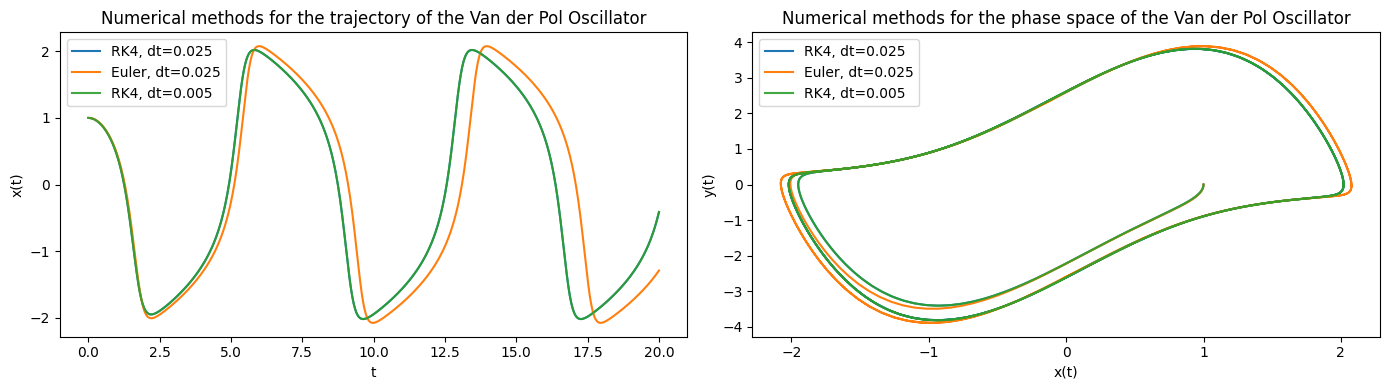

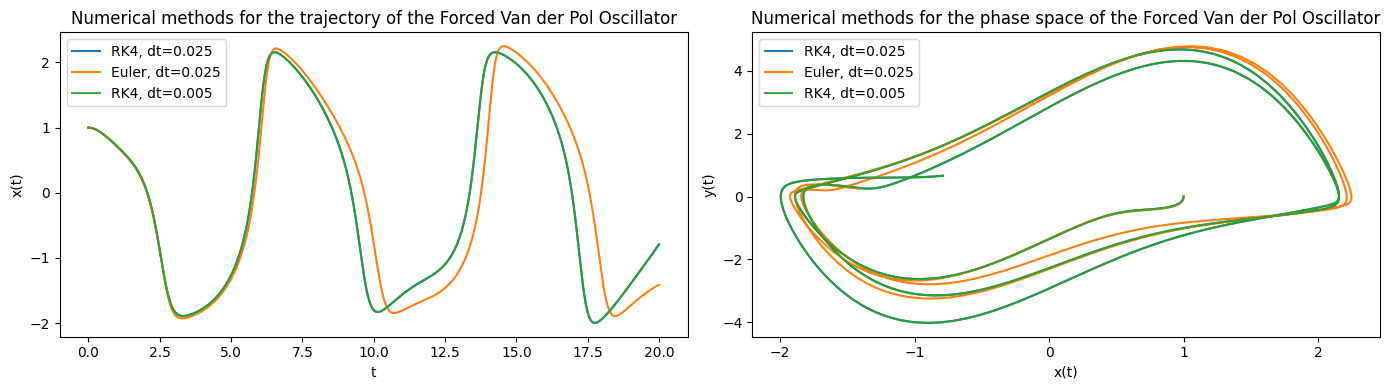

In [3]:
#Our two oscillators

oscillators = {
    "Van der Pol": {
        "run_ode": lambda t, y: van_der_pol(t, y, mu=mu),
        "forced": False,
    },
    "Forced Van der Pol": {
        "run_ode": lambda t, y: forced_van_der_pol(t, y, mu=mu, A=A, omega=omega),
        "forced": True,
    },
}

#Mega struct to store all numerical results and data, to carry over between cells
numerical_results_mega_struct = {}
for name, params in oscillators.items():
    func = params["run_ode"]

    #Generate trajectories with different step sizes + methods
    time_rk4, states_rk4 = rk4(func, start_time, end_time, dt, initial_state)
    time_euler, states_euler = euler(func, start_time, end_time, dt, initial_state)
    time_low_train, states_low_train = rk4(func, start_time, end_time, high_acc_dt, initial_state)

    #The extrapolation interval, used for last evaluation
    time_low_eval, states_low_eval = rk4(func, start_time, extrapolate_time, high_acc_dt, initial_state)
    stride = int(round(dt / high_acc_dt))
    t_eval = time_low_eval[::stride]
    states_low_eval = states_low_eval[::stride]

    #add noise to the trajectory and velocity
    x_rk4 = states_rk4[:, 0]
    y_rk4 = states_rk4[:, 1]
    x_with_noise = x_rk4 + np.random.normal(0.0, sigma, size=x_rk4.shape)
    y_with_noise = y_rk4 + np.random.normal(0.0, sigma, size=y_rk4.shape)

    numerical_results_mega_struct[name] = {
        "forced": params["forced"],
        "func": func,
        "time_rk4": time_rk4,
        "states_rk4": states_rk4,
        "states_euler": states_euler,
        "states_low_train": states_low_train,
        "states_low_eval": states_low_eval,
        "x_rk4": x_rk4,
        "y_rk4": y_rk4,
        "x_with_noise": x_with_noise,
        "y_with_noise": y_with_noise,
        "t_eval": t_eval,
        "x_low_eval": states_low_eval[:, 0],
        "y_low_eval": states_low_eval[:, 1],
    }

    fig_num, axs_num = plt.subplots(1, 2, figsize=(14, 4))
    
    #Trajectory subplot
    axs_num[0].plot(time_rk4, states_rk4[:, 0], label=f"RK4, dt={dt:.3f}")
    axs_num[0].plot(time_euler, states_euler[:, 0], label=f"Euler, dt={dt:.3f}")
    axs_num[0].plot(time_low_train, states_low_train[:, 0], label=f"RK4, dt={high_acc_dt:.3f}", alpha=0.9)
    axs_num[0].set_xlabel("t")
    axs_num[0].set_ylabel("x(t)")
    axs_num[0].set_title(f"Numerical methods for the trajectory of the {name} Oscillator")
    axs_num[0].legend()

    #Phase space subplot
    axs_num[1].plot(states_rk4[:, 0], states_rk4[:, 1], label=f"RK4, dt={dt:.3f}")
    axs_num[1].plot(states_euler[:, 0], states_euler[:, 1], label=f"Euler, dt={dt:.3f}")
    axs_num[1].plot(states_low_train[:, 0], states_low_train[:, 1], label=f"RK4, dt={high_acc_dt:.3f}", alpha=0.9)
    axs_num[1].set_xlabel("x(t)")
    axs_num[1].set_ylabel("y(t)")
    axs_num[1].set_title(f"Numerical methods for the phase space of the {name} Oscillator")
    axs_num[1].legend()

    fig_num.tight_layout()
    fig_num.savefig(f"numerical_compare_{name}.png")
    plt.show()

### This is where we train the FFNN and plot its loss

Note: for all the ML methods I use, a BestLoss helper class in util.py is used to save and automatically select the model from the epoch with the best loss.

Epoch 0 Loss 2.0576835348365012
Epoch 100 Loss 1.5768938436639146
Epoch 200 Loss 1.2489502604088087
Epoch 300 Loss 0.12089619437667463
Epoch 400 Loss 0.08402797483493772
Epoch 500 Loss 0.03263880138851693
Epoch 600 Loss 0.039049656078051984
Epoch 700 Loss 0.013236257974314184
Epoch 800 Loss 0.014377055796660883
Epoch 900 Loss 0.026981629101040957
Epoch 1000 Loss 0.012498071499764176
Epoch 1100 Loss 0.018441139514001084
Epoch 1200 Loss 0.011799488946814067
Epoch 1300 Loss 0.012772719097903902
Epoch 1400 Loss 0.0165364153278566
Epoch 1500 Loss 0.013103775249866213
Epoch 1600 Loss 0.013194739474413844
Epoch 1700 Loss 0.013846593639219223
Epoch 1800 Loss 0.015164942167857465
Epoch 1900 Loss 0.022370683243230785


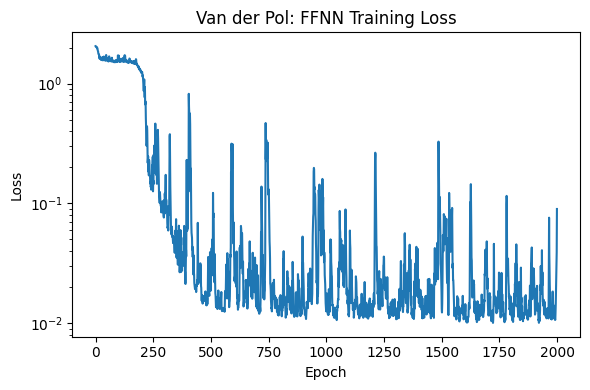

Epoch 0 Loss 2.019309998898024
Epoch 100 Loss 1.5166064351983135
Epoch 200 Loss 0.415073100919283
Epoch 300 Loss 0.04450354360499781
Epoch 400 Loss 0.014787280922767225
Epoch 500 Loss 0.020922767068172216
Epoch 600 Loss 0.015873140108989048
Epoch 700 Loss 0.0218141885583618
Epoch 800 Loss 0.015780459805746352
Epoch 900 Loss 0.04312905169716488
Epoch 1000 Loss 0.014673765632469258
Epoch 1100 Loss 0.01560398464331801
Epoch 1200 Loss 0.011743190739020129
Epoch 1300 Loss 0.012808237734079807
Epoch 1400 Loss 0.03078621547766839
Epoch 1500 Loss 0.017957397405820877
Epoch 1600 Loss 0.053681897257597706
Epoch 1700 Loss 0.04106289719913932
Epoch 1800 Loss 0.011908321468143279
Epoch 1900 Loss 0.013101812524165255


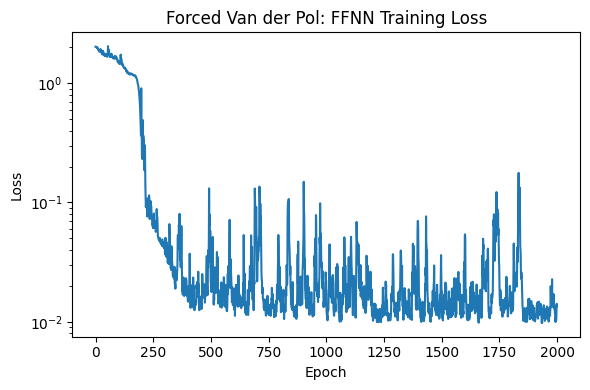

In [4]:
for name, info in numerical_results_mega_struct.items():
    t_interval = info["time_rk4"]
    noisy_x_points = info["x_with_noise"]

    ff_deep, loss_hist = train_ffnn(t_interval, noisy_x_points, epochs=FFNN_EPOCHS, lr=LR_FFNN, device=device)

    info["ff_model"] = ff_deep
    info["ffnn_loss_history"] = loss_hist

    plt.figure(figsize=(6, 4))
    plt.plot(loss_hist)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{name}: FFNN Training Loss")
    plt.tight_layout()

    plt.savefig(f"ffnn_loss_{name}.png")
    plt.show()

### This is where we train the Neural ODE and plot its loss

Note: The Neural ODE requires a larger number of epochs to converge than the other methods, change it in the first code cell as needed.
Also, my Neural ODE uses the forward Euler method for rollout, consider adding a different one if you have the computational resources.

Epoch # 0 Loss 2.789430618286133
time: 0.12578320503234863
Epoch # 100 Loss 1.9109100103378296
time: 11.505354881286621
Epoch # 200 Loss 1.6601958274841309
time: 11.797935247421265
Epoch # 300 Loss 1.9557157754898071
time: 11.747235536575317
Epoch # 400 Loss 1.8003933429718018
time: 11.567895889282227
Epoch # 500 Loss 0.7557014226913452
time: 11.930434465408325
Epoch # 600 Loss 0.407005250453949
time: 11.798083305358887
Epoch # 700 Loss 0.389516681432724
time: 11.833907127380371
Epoch # 800 Loss 0.39815184473991394
time: 12.106345176696777
Epoch # 900 Loss 0.38378432393074036
time: 11.78642225265503
Epoch # 1000 Loss 0.36600109934806824
time: 11.782299280166626
Epoch # 1100 Loss 0.37600192427635193
time: 11.527985334396362
Epoch # 1200 Loss 0.37332087755203247
time: 11.653874158859253
Epoch # 1300 Loss 0.3568744659423828
time: 11.531551361083984
Epoch # 1400 Loss 0.34672653675079346
time: 11.475841045379639
Epoch # 1500 Loss 0.3597603440284729
time: 11.671587705612183
Epoch # 1600 Loss

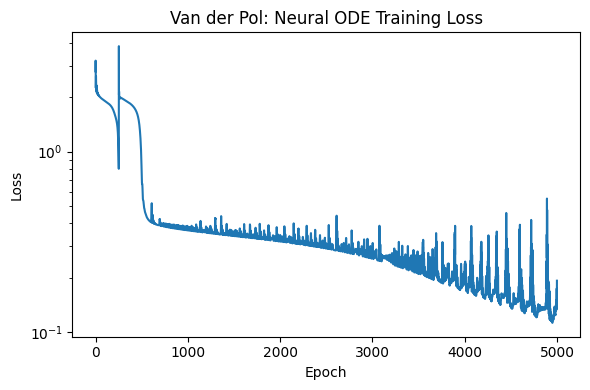

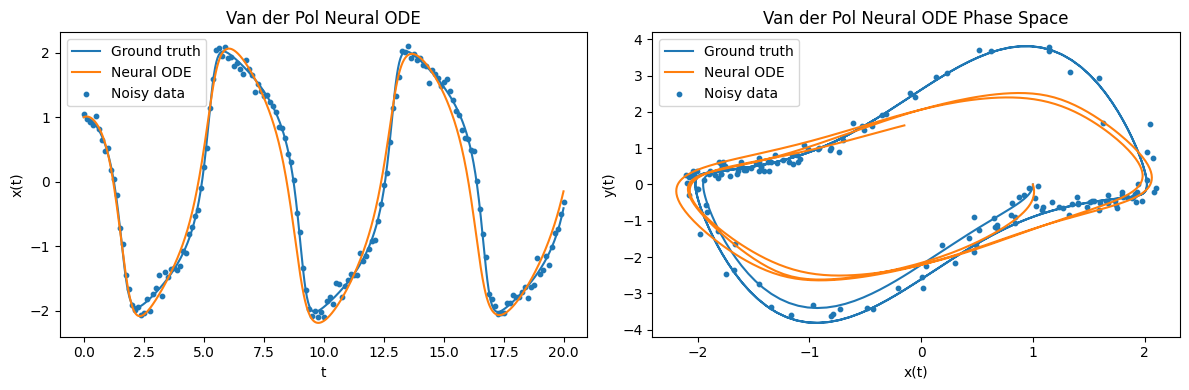

Epoch # 0 Loss 5.315677165985107
time: 0.10947513580322266
Epoch # 100 Loss 1.9653863906860352
time: 11.879173040390015
Epoch # 200 Loss 1.8393734693527222
time: 11.768912076950073
Epoch # 300 Loss 1.0806081295013428
time: 12.000069856643677
Epoch # 400 Loss 0.4687211513519287
time: 11.794981479644775
Epoch # 500 Loss 0.4844721555709839
time: 11.387964725494385
Epoch # 600 Loss 0.46784040331840515
time: 12.036644697189331
Epoch # 700 Loss 0.4356234669685364
time: 12.368003845214844
Epoch # 800 Loss 0.44011107087135315
time: 12.11159896850586
Epoch # 900 Loss 0.4519171118736267
time: 12.220448017120361
Epoch # 1000 Loss 0.4277298152446747
time: 11.538682699203491
Epoch # 1100 Loss 0.4480123221874237
time: 11.913177728652954
Epoch # 1200 Loss 0.4505408704280853
time: 11.555268049240112
Epoch # 1300 Loss 0.42067021131515503
time: 11.53291630744934
Epoch # 1400 Loss 0.4128021001815796
time: 11.307466268539429
Epoch # 1500 Loss 0.42848441004753113
time: 11.504843950271606
Epoch # 1600 Loss 

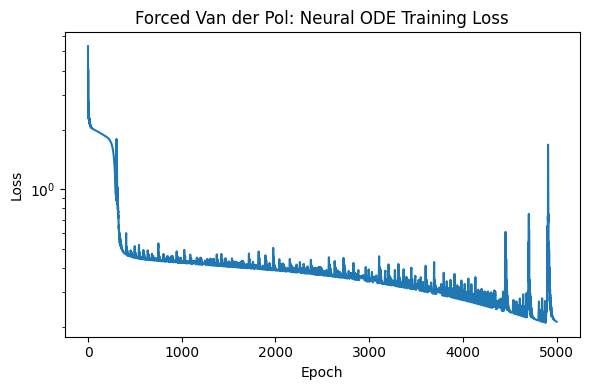

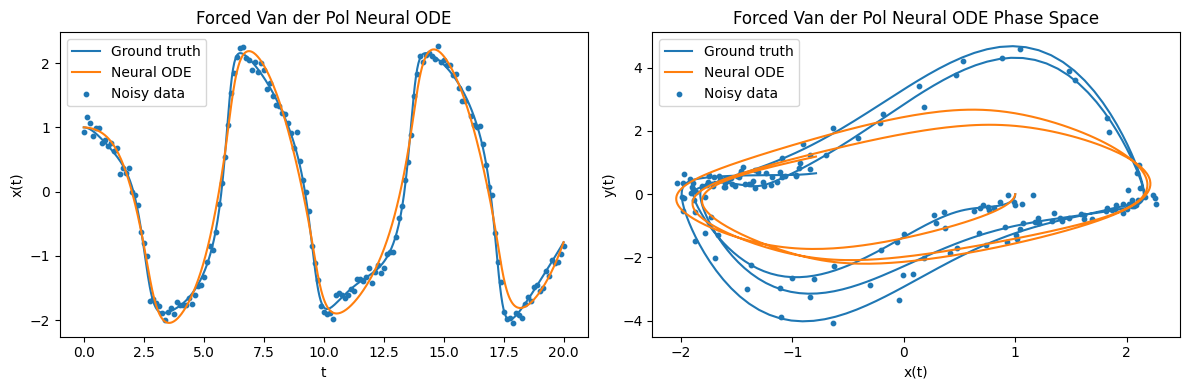

In [5]:
for name, info in numerical_results_mega_struct.items():
    time_interval = info["time_rk4"]
    states = info["states_rk4"]
    x_clean = info["x_rk4"]
    y_clean = info["y_rk4"]
    x_noisy = info["x_with_noise"]
    y_noisy = info["y_with_noise"]

    n_ode, predicted_z_states, loss_hist = train_neural_ode(states, dt, device=device, epochs=NODE_EPOCHS, width=128, lr=LR_NODE, t0=start_time)

    info["neural_ode"] = n_ode
    info["neural_ode_predicted_states"] = predicted_z_states
    info["node_loss_history"] = loss_hist

    plt.figure(figsize=(6, 4))
    plt.plot(loss_hist)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{name}: Neural ODE Training Loss")
    plt.tight_layout()
    plt.savefig(f"neural_ode_loss_{name}.png")
    plt.show()

    steps = len(time_interval)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(time_interval, x_clean, label="Ground truth")
    ax[0].plot(time_interval, predicted_z_states[:, 0], label="Neural ODE")
    ax[0].scatter(time_interval[::5], x_noisy[::5], s=10, label="Noisy data")
    ax[0].set_xlabel("t")
    ax[0].set_ylabel("x(t)")
    ax[0].set_title(f"{name} Neural ODE")
    ax[0].legend()

    ax[1].plot(x_clean, y_clean, label="Ground truth")
    ax[1].plot(predicted_z_states[:, 0], predicted_z_states[:, 1], label="Neural ODE")
    ax[1].scatter(x_noisy[::5], y_noisy[::5], s=10, label="Noisy data")
    ax[1].set_xlabel("x(t)")
    ax[1].set_ylabel("y(t)")
    ax[1].set_title(f"{name} Neural ODE Phase Space")
    ax[1].legend()

    plt.tight_layout()
    plt.savefig(f"neural_ode_fit_{name}.png")
    plt.show()

### A helper cell to see the learned vector field and the ground truth plot for the Neural ODE

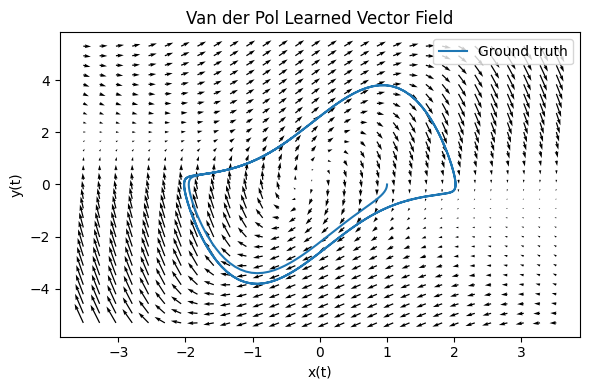

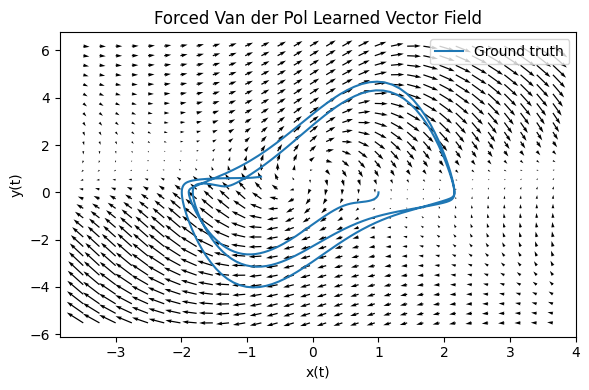

In [6]:
rng = np.random.default_rng(SEED)

for name, info in numerical_results_mega_struct.items():
    time_interval = info["time_rk4"]
    states = info["states_rk4"]
    x_clean = info["x_rk4"]
    y_clean = info["y_rk4"]
    x_noisy = info["x_with_noise"]
    y_noisy = info["y_with_noise"]
    n_ode = info["neural_ode"]

    xmin, xmax = float(np.min(x_clean) - 1.5), float(np.max(x_clean) + 1.5)
    ymin, ymax = float(np.min(y_clean) - 1.5), float(np.max(y_clean) + 1.5)

    arrow_start_x, arrow_start_y = np.meshgrid(np.linspace(xmin, xmax, 30), np.linspace(ymin, ymax, 30))
    time_grid = torch.tensor(np.stack([arrow_start_x.ravel(), arrow_start_y.ravel()], axis=1), dtype=torch.float32, device=device)

    with torch.no_grad():
        vec = n_ode(time_grid, start_time).cpu().numpy()

    arrow_end_x = vec[:, 0].reshape(arrow_start_x.shape)
    arrow_end_y = vec[:, 1].reshape(arrow_start_y.shape)

    plt.figure(figsize=(6, 4))
    plt.quiver(arrow_start_x, arrow_start_y, arrow_end_x, arrow_end_y)
    plt.plot(x_clean, y_clean, label="Ground truth")
    plt.xlabel("x(t)")
    plt.ylabel("y(t)")
    plt.title(f"{name} Learned Vector Field")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"learned_vector_field_{name}.png")
    plt.show()

### This cell trains the two PINNs, one which samples collocation points from t = 0 to 100, and one with collocation points from t= 0 to 1000.
### It then plots the trajectory and phase space plots for the precise RK4, the FFNN, the Neural ODE, and the two PINNs on both the training and extrapolation intervals.

Note: For convenience in gradient calculation a pytorch version of the VDP oscillator is calculated in train_pinn and is unaffected by the function in the second cell.

Epoch # 0 Loss 32.805606842041016
Epoch # 1 Loss 32.753990173339844
Epoch # 2 Loss 31.831790924072266
Epoch # 3 Loss 29.15434455871582
Epoch # 4 Loss 28.301795959472656
Epoch # 5 Loss 28.731666564941406
Epoch # 6 Loss 28.18868637084961
Epoch # 7 Loss 26.841352462768555
Epoch # 8 Loss 25.7036190032959
Epoch # 9 Loss 25.192068099975586
Epoch # 100 Loss 17.995874404907227
Epoch # 200 Loss 12.2764253616333
Epoch # 300 Loss 6.505054950714111
Epoch # 400 Loss 3.8599438667297363
Epoch # 500 Loss 2.7496399879455566
Epoch # 600 Loss 1.9009684324264526
Epoch # 700 Loss 1.272308588027954
Epoch # 800 Loss 0.9479877352714539
Epoch # 900 Loss 0.6597025394439697
Epoch # 1000 Loss 0.7038336992263794
Epoch # 1100 Loss 0.4186551570892334
Epoch # 1200 Loss 0.4617904722690582
Epoch # 1300 Loss 0.37663692235946655
Epoch # 1400 Loss 0.3134593367576599
Epoch # 1500 Loss 0.41244083642959595
Epoch # 1600 Loss 0.27538877725601196
Epoch # 1700 Loss 0.39782223105430603
Epoch # 1800 Loss 0.2526063919067383
Epoch #

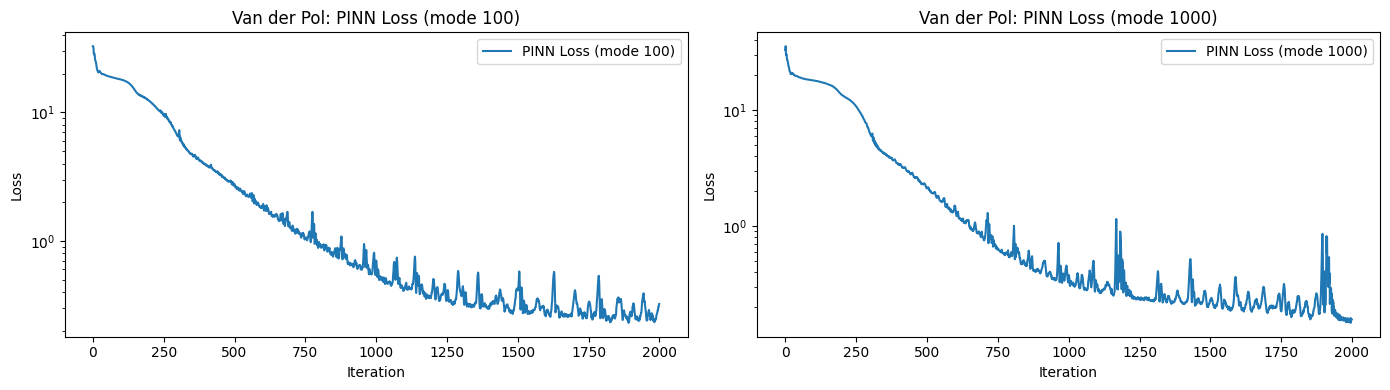

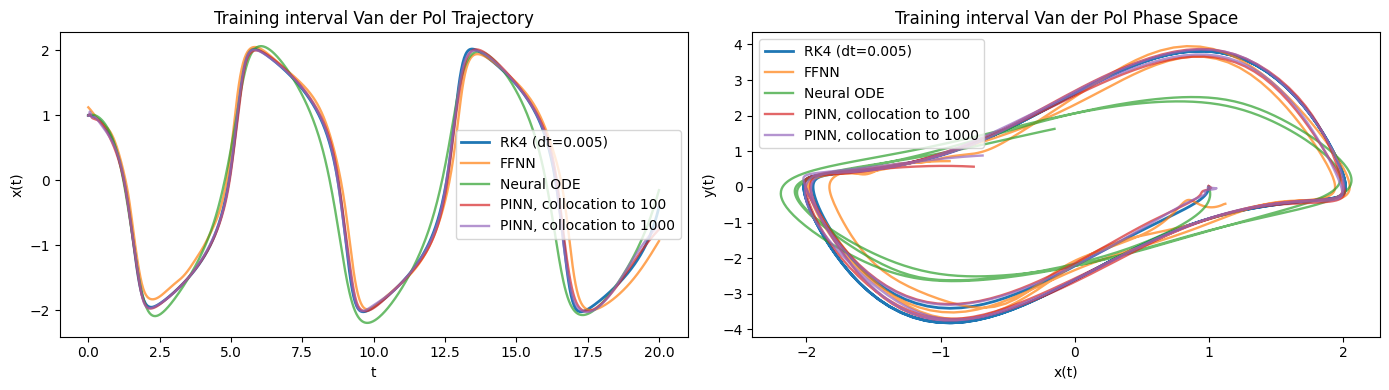

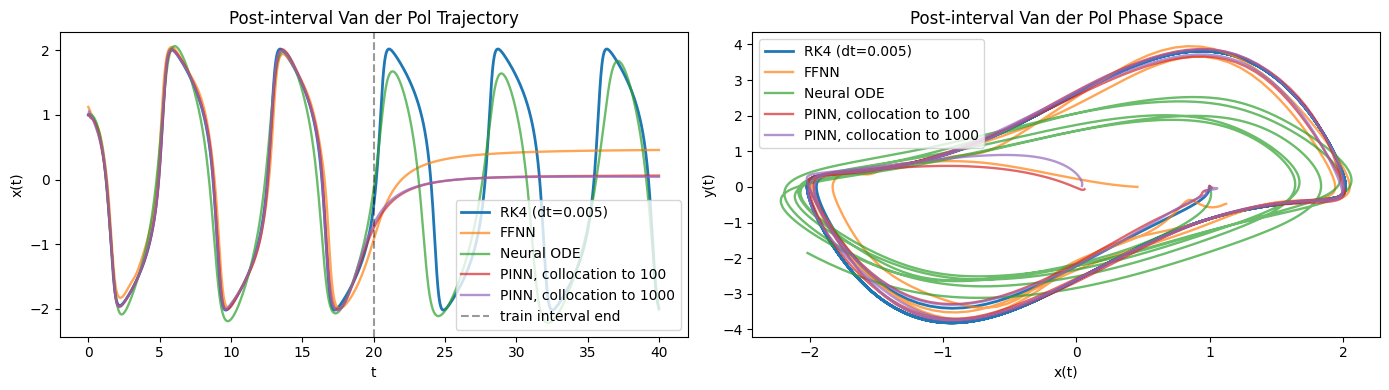

Epoch # 0 Loss 31.462453842163086
Epoch # 1 Loss 36.026771545410156
Epoch # 2 Loss 31.35969352722168
Epoch # 3 Loss 30.00406265258789
Epoch # 4 Loss 30.081523895263672
Epoch # 5 Loss 29.122772216796875
Epoch # 6 Loss 28.15520477294922
Epoch # 7 Loss 27.009397506713867
Epoch # 8 Loss 26.194440841674805
Epoch # 9 Loss 25.659324645996094
Epoch # 100 Loss 19.572017669677734
Epoch # 200 Loss 15.327831268310547
Epoch # 300 Loss 10.92397403717041
Epoch # 400 Loss 5.170091152191162
Epoch # 500 Loss 3.2740674018859863
Epoch # 600 Loss 1.9287724494934082
Epoch # 700 Loss 1.1034080982208252
Epoch # 800 Loss 0.8250817060470581
Epoch # 900 Loss 0.7499011754989624
Epoch # 1000 Loss 0.6498225331306458
Epoch # 1100 Loss 0.6105291247367859
Epoch # 1200 Loss 0.5507962703704834
Epoch # 1300 Loss 0.565791130065918
Epoch # 1400 Loss 0.5688086152076721
Epoch # 1500 Loss 0.6575309038162231
Epoch # 1600 Loss 0.5596068501472473
Epoch # 1700 Loss 0.5763349533081055
Epoch # 1800 Loss 0.5369564890861511
Epoch # 1

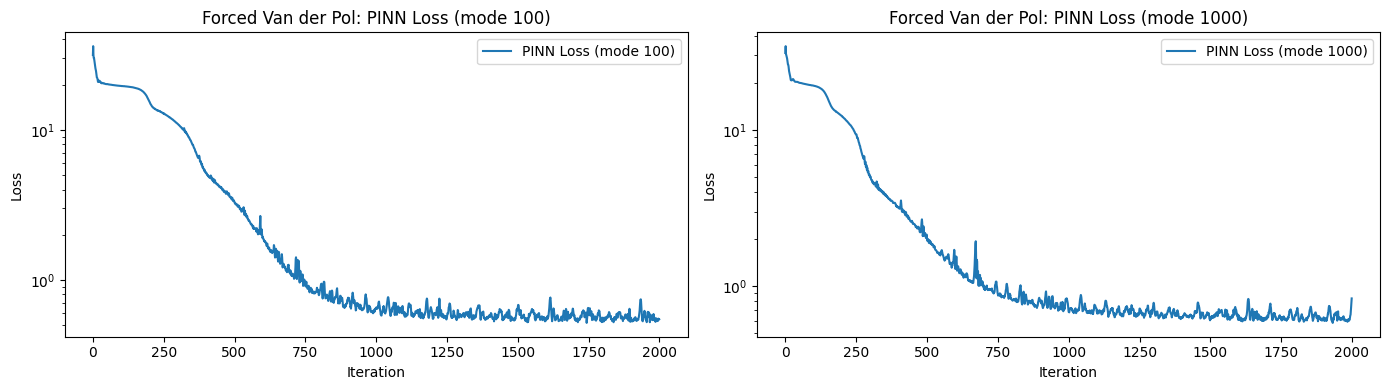

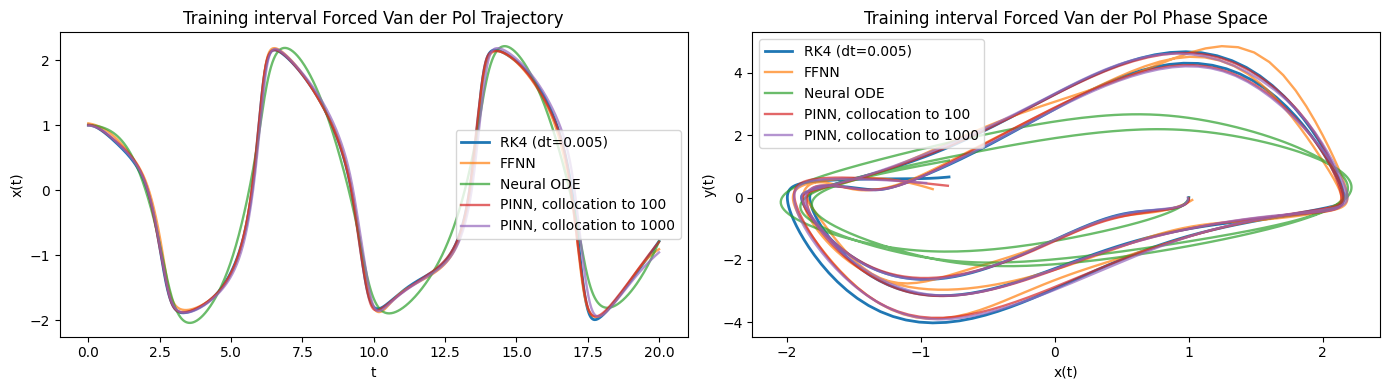

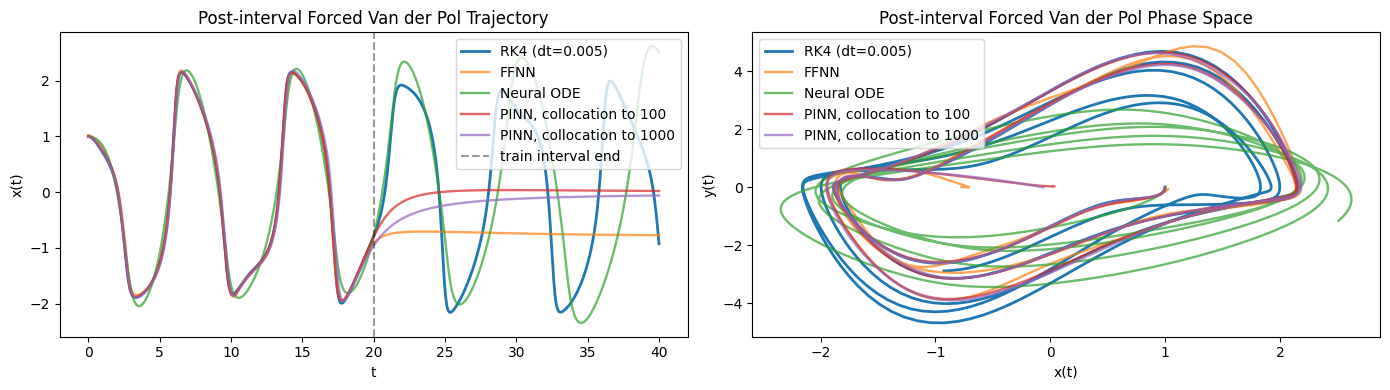

In [7]:


for name, info in numerical_results_mega_struct.items():
    t_train = info["time_rk4"]
    t_eval = info["t_eval"]
    traj_train = info["states_rk4"]
    x_noisy = info["x_with_noise"]
    y_noisy = info["y_with_noise"]

    ff_model = info["ff_model"]

    pinn_width = 128
    pinn_depth = 6


    with torch.no_grad():
        t_eval_tensor = torch.tensor(t_eval, dtype=torch.float32, device=device).view(-1, 1)
        x_ffnn = ff_model(t_eval_tensor).cpu().numpy().squeeze()
    y_ffnn = np.gradient(x_ffnn, t_eval)

    # Neural ODE rollout on longer time interval, using the learned vector field, to see how it does on extrapolation
    node = info["neural_ode"]
    h0 = torch.tensor(traj_train[0], dtype=torch.float32, device=device)
    with torch.no_grad():
        h_node = euler_for_node(node, h0, dt, len(t_eval), t0=start_time)
        h_node = h_node.cpu().numpy()
    x_node = h_node[:, 0]
    y_node = h_node[:, 1]

    # Training the Pinns on the noisy data and the two collocation point scenarios
    pinn_model_100, pinn_loss_100 = train_pinn(start_time, end_time, initial_state, mu, A, omega, info["forced"], t_train, x_noisy, y_noisy, PINN_ITERS, 3000, 1.0, 10.0, 5.0, LR_PINN, pinn_width, pinn_depth, device, 100, "100")
    x_pinn_100, y_pinn_100 = pinn_predict(pinn_model_100, t_eval, device=device)
    pinn_model_1000, pinn_loss_1000 = train_pinn(start_time, end_time, initial_state, mu, A, omega, info["forced"], t_train, x_noisy, y_noisy, PINN_ITERS, 3000, 1.0, 10.0, 5.0, LR_PINN, pinn_width, pinn_depth, device, 100, "1000")
    x_pinn_1000, y_pinn_1000 = pinn_predict(pinn_model_1000, t_eval, device=device)

    tag = "forced" if info["forced"] else "unforced"

    #pinn loss plots
    fig_loss, axs_loss = plt.subplots(1, 2, figsize=(14, 4))
    axs_loss[0].plot(pinn_loss_100, label="PINN Loss (mode 100)", linewidth=1.5)
    axs_loss[0].set_yscale("log")
    axs_loss[0].set_xlabel("Iteration")
    axs_loss[0].set_ylabel("Loss")
    axs_loss[0].set_title(f"{name}: PINN Loss (mode 100)")
    axs_loss[0].legend()

    axs_loss[1].plot(pinn_loss_1000, label="PINN Loss (mode 1000)", linewidth=1.5)
    axs_loss[1].set_yscale("log")
    axs_loss[1].set_xlabel("Iteration")
    axs_loss[1].set_ylabel("Loss")
    axs_loss[1].set_title(f"{name}: PINN Loss (mode 1000)")
    axs_loss[1].legend()

    fig_loss.tight_layout()
    fig_loss.savefig(f"pinn_loss_{tag}.png")
    plt.figure(fig_loss.number)
    plt.show()

    x_low = info["x_low_eval"]
    y_low = info["y_low_eval"]

    info["x_ffnn_eval"] = x_ffnn
    info["y_ffnn_eval"] = y_ffnn
    info["x_node_eval"] = x_node
    info["y_node_eval"] = y_node
    info["x_pinn_100_eval"] = x_pinn_100
    info["y_pinn_100_eval"] = y_pinn_100
    info["x_pinn_1000_eval"] = x_pinn_1000
    info["y_pinn_1000_eval"] = y_pinn_1000

    tag = "forced" if info["forced"] else "unforced"


    #easier to just use a mask compared to running twice
    mask_train = t_eval <= end_time

    fig_train, axs_train = plt.subplots(1, 2, figsize=(14, 4))
    
    #Trajectory
    axs_train[0].plot(t_eval[mask_train], x_low[mask_train], label=f"RK4 (dt={high_acc_dt:.3f})", linewidth=2)
    axs_train[0].plot(t_eval[mask_train], x_ffnn[mask_train], label="FFNN", linewidth=1.7, alpha = 0.7)
    axs_train[0].plot(t_eval[mask_train], x_node[mask_train], label="Neural ODE", linewidth=1.7, alpha = 0.7)
    axs_train[0].plot(t_eval[mask_train], x_pinn_100[mask_train], label="PINN, collocation to 100", linewidth=1.7, alpha = 0.7)
    axs_train[0].plot(t_eval[mask_train], x_pinn_1000[mask_train], label="PINN, collocation to 1000", linewidth=1.7, alpha = 0.7)
    axs_train[0].set_xlabel("t")
    axs_train[0].set_ylabel("x(t)")
    axs_train[0].set_title(f"Training interval {name} Trajectory")
    axs_train[0].legend()

    #Phase space
    axs_train[1].plot(x_low[mask_train], y_low[mask_train], label=f"RK4 (dt={high_acc_dt:.3f})", linewidth=2)
    axs_train[1].plot(x_ffnn[mask_train], y_ffnn[mask_train], label="FFNN", linewidth=1.7, alpha = 0.7)
    axs_train[1].plot(x_node[mask_train], y_node[mask_train], label="Neural ODE", linewidth=1.7, alpha = 0.7)
    axs_train[1].plot(x_pinn_100[mask_train], y_pinn_100[mask_train], label="PINN, collocation to 100", linewidth=1.7, alpha = 0.7)
    axs_train[1].plot(x_pinn_1000[mask_train], y_pinn_1000[mask_train], label="PINN, collocation to 1000", linewidth=1.7, alpha = 0.7)
    axs_train[1].set_xlabel("x(t)")
    axs_train[1].set_ylabel("y(t)")
    axs_train[1].set_title(f"Training interval {name} Phase Space")
    axs_train[1].legend()

    fig_train.tight_layout()
    fig_train.savefig(f"ml_compare_train_{tag}.png")
    plt.figure(fig_train.number)
    plt.show()

    # the extrapolation
    fig_ext, axs_ext = plt.subplots(1, 2, figsize=(14, 4))
    
    # Trajectory
    axs_ext[0].plot(t_eval, x_low, label=f"RK4 (dt={high_acc_dt:.3f})", linewidth=2)
    axs_ext[0].plot(t_eval, x_ffnn, label="FFNN", linewidth=1.7, alpha = 0.7)
    axs_ext[0].plot(t_eval, x_node, label="Neural ODE", linewidth=1.7, alpha = 0.7)
    axs_ext[0].plot(t_eval, x_pinn_100, label="PINN, collocation to 100", linewidth=1.7, alpha = 0.7)
    axs_ext[0].plot(t_eval, x_pinn_1000, label="PINN, collocation to 1000", linewidth=1.7, alpha = 0.7)
    axs_ext[0].axvline(end_time, color="k", linestyle="--", alpha=0.4, label="train interval end")
    axs_ext[0].set_xlabel("t")
    axs_ext[0].set_ylabel("x(t)")
    axs_ext[0].set_title(f"Post-interval {name} Trajectory")
    axs_ext[0].legend()
    
    #Phase space
    axs_ext[1].plot(x_low, y_low, label=f"RK4 (dt={high_acc_dt:.3f})", linewidth=2)
    axs_ext[1].plot(x_ffnn, y_ffnn, label="FFNN", linewidth=1.7, alpha = 0.7)
    axs_ext[1].plot(x_node, y_node, label="Neural ODE", linewidth=1.7, alpha = 0.7)
    axs_ext[1].plot(x_pinn_100, y_pinn_100, label="PINN, collocation to 100", linewidth=1.7, alpha = 0.7)
    axs_ext[1].plot(x_pinn_1000, y_pinn_1000, label="PINN, collocation to 1000", linewidth=1.7, alpha = 0.7)
    axs_ext[1].set_xlabel("x(t)")
    axs_ext[1].set_ylabel("y(t)")
    axs_ext[1].set_title(f"Post-interval {name} Phase Space")
    axs_ext[1].legend()
    
    fig_ext.tight_layout()
    fig_ext.savefig(f"ml_compare_extrapolated_{tag}.png")
    plt.figure(fig_ext.number)
    plt.show()

    #Saving the pickle of the results

    # with open(f"results_{name}.pkl", "wb") as f:
    #     pickle.dump(info, f)
